In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('ipl.csv')

In [ ]:
df
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [ ]:
print(f"Your Data have {df.shape[0]} rows and {df.shape[1]} columns")

Your Data have 74 rows and 20 columns


In [ ]:
df.isna().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [ ]:
# WHich team won the most matches
match_wins = df['match_winner'].value_counts()

Text(0.5, 1.0, 'Which team won the most matches')

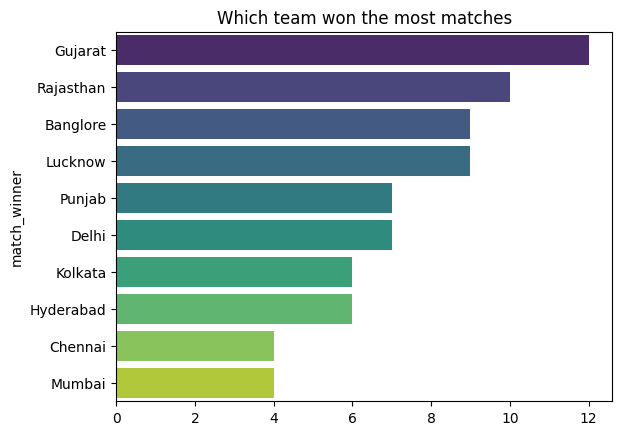

In [ ]:
match_wins
sns.barplot(y = match_wins.index, x = match_wins.values, palette = 'viridis')
plt.title('Which team won the most matches')

In [ ]:
df.columns.tolist()

['match_id',
 'date',
 'venue',
 'team1',
 'team2',
 'stage',
 'toss_winner',
 'toss_decision',
 'first_ings_score',
 'first_ings_wkts',
 'second_ings_score',
 'second_ings_wkts',
 'match_winner',
 'won_by',
 'margin',
 'player_of_the_match',
 'top_scorer',
 'highscore',
 'best_bowling',
 'best_bowling_figure']

Text(0.5, 1.0, 'Toss Decision')

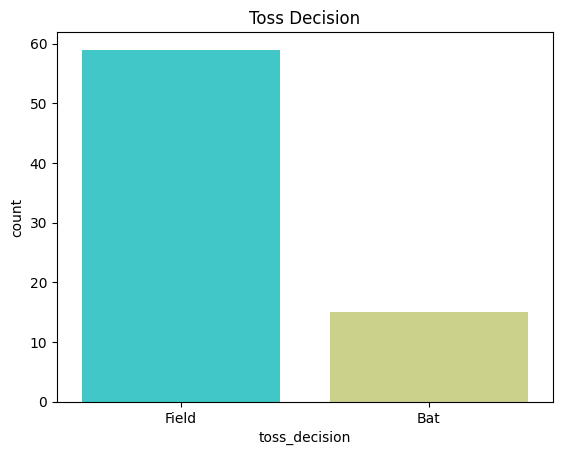

In [ ]:
# Tos making trends
sns.countplot(x = 'toss_decision', data = df, palette = 'rainbow')
plt.title('Toss Decision')

In [ ]:
# How many chances where Toss_winner  = Match_winner
countm = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
countm
percentagem = (countm*100)/df.shape[0]
percentagem

np.float64(48.648648648648646)

Text(0.5, 1.0, 'How do team win')

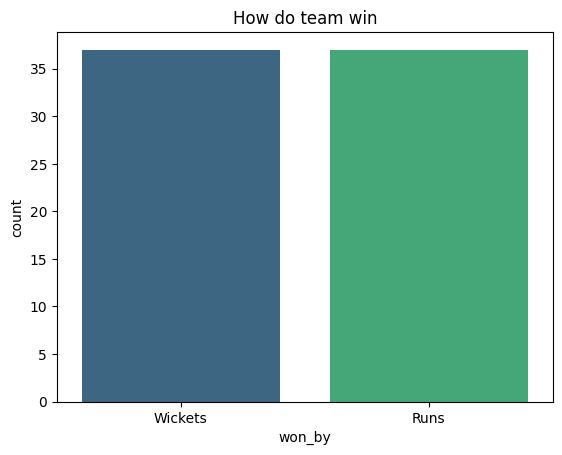

In [ ]:
# How do team win (Run vs Wicket)
sns.countplot(x = 'won_by', data = df, palette = 'viridis')
plt.title('How do team win')

In [ ]:
# Most player of the match award
count = df['player_of_the_match'].value_counts().head(10)
count

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


Text(0.5, 1.0, 'Most player of the match award')

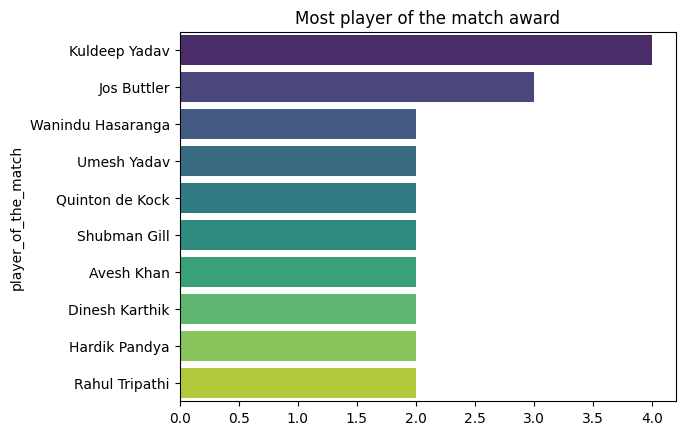

In [ ]:
sns.barplot(y = count.index, x = count.values, palette = 'viridis')
plt.title('Most player of the match award')


In [ ]:
# Top Scores
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head()
high

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377
KL Rahul,351
Shubman Gill,288
Faf du Plessis,257


<Axes: ylabel='top_scorer'>

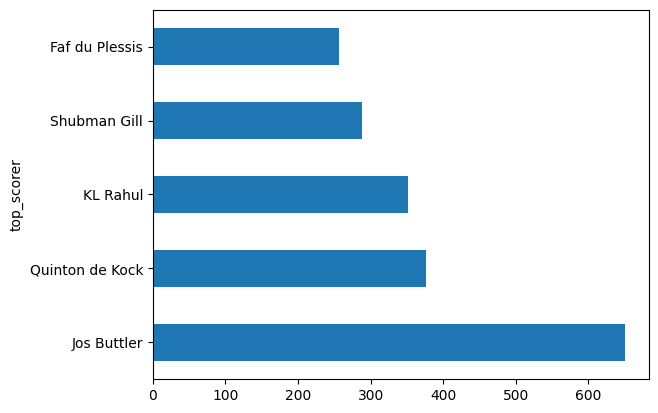

In [ ]:
high.plot(kind = 'barh')

<Axes: ylabel='best_bowling'>

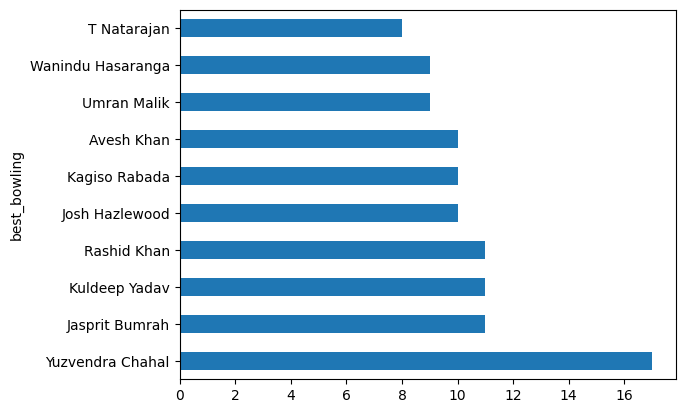

In [ ]:
# 10 best bowling figure
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending = False).head(10)
top_bowlers.plot(kind = 'barh')

In [ ]:
# Most matches played by venue
venue_count = df['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

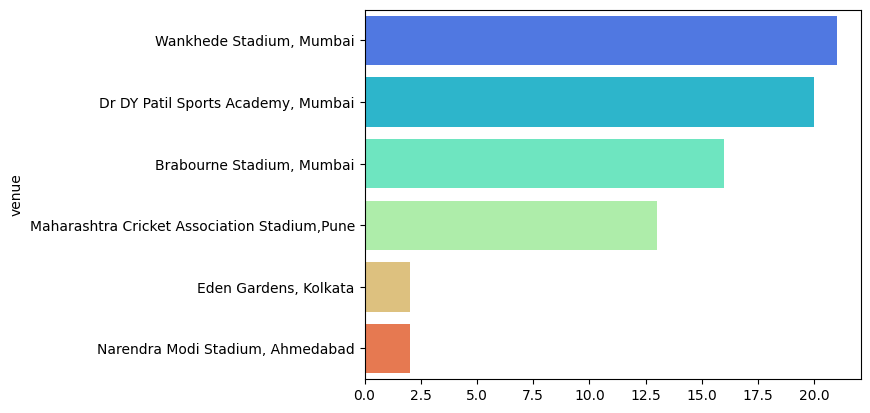

In [ ]:
sns.barplot(y = venue_count.index, x = venue_count.values, palette = 'rainbow')

In [ ]:
# Who won the highest margin by run
df[df['won_by'] == 'Runs'].sort_values(by = 'margin', ascending = False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


In [ ]:
# Which player had the highest individual score
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [ ]:
# Which bowlers had the best bowling figure?
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


In [ ]:
# Which bowlers had the best bowling figure?
df['minrun_w_wicket'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['minrun_w_wicket'] = df['minrun_w_wicket'].astype(int)

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets,minrun_w_wicket
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,3
